# Lab Assignment 4: Support Vector Machines

In this exercise, we return to the wine quality dataset. However, this time, we will attempt to separate various pieces of cloathing using a Support Vector Machine (SVM). Below, we gather the data and preprocess it for you. As your task, you need to implement an SVM solver, perform finetuning and classification, and finally, show your results using a confusion matrix.

## Library installation
In this lab we will use the `cvxopt` package, [whose documentation can be found here](https://cvxopt.org/userguide/index.html).

We are running version 1.3.2 of `cvxopt`.

In [48]:
!pip install cvxopt

### Package Imports

In [49]:
## =======================================================
## Import Key Packages
## =======================================================
## Standard Fare
import numpy as np
from scipy.io import loadmat
import time

## CVX Opt
import cvxopt
from cvxopt import solvers
from cvxopt import matrix
!pip install scikit-learn
from sklearn.model_selection import train_test_split
import pandas as pd

solvers.options['show_progress'] = False

## Accessing the Data

In [50]:
training_data = pd.read_csv('./fashion-mnist_train.csv')

y = training_data['label']
X = training_data.drop('label',axis=1)

X = X[:2000]
y = y[:2000]

train_samples, test_samples, train_samples_labels, test_samples_labels = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)

test_samples_labels=np.squeeze(test_samples_labels)
train_samples_labels=np.squeeze(train_samples_labels)

In [51]:
label_to_title = {0: 'T-shirt/top', 
                  1:'Trouser', 
                  2:'Pullover', 
                  3:'Dress', 
                  4:'Coat', 
                  5:'Sandal',
                  6:'Shirt', 
                  7:'Sneaker', 
                  8:'Bag',
                  9:'Ankle boot'}

In [52]:
print(np.unique(train_samples_labels))
print(np.unique(test_samples_labels))

for i in np.unique(train_samples_labels):
    print(f' There are {sum(train_samples_labels==i)} instances of label #{i}:{label_to_title[i]} in the Train dataset')

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
 There are 197 instances of label #0:T-shirt/top in the Train dataset
 There are 182 instances of label #1:Trouser in the Train dataset
 There are 187 instances of label #2:Pullover in the Train dataset
 There are 190 instances of label #3:Dress in the Train dataset
 There are 200 instances of label #4:Coat in the Train dataset
 There are 160 instances of label #5:Sandal in the Train dataset
 There are 188 instances of label #6:Shirt in the Train dataset
 There are 165 instances of label #7:Sneaker in the Train dataset
 There are 168 instances of label #8:Bag in the Train dataset
 There are 163 instances of label #9:Ankle boot in the Train dataset


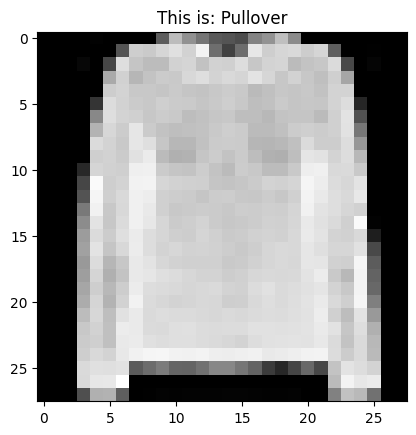

In [53]:
import matplotlib.pyplot as plt
import random

ind = random.randint(0,2000)
plt.imshow(X[ind:ind+1].values.reshape(28,28),cmap='gray')
plt.title(f'This is: {label_to_title[y[ind:ind+1].values[0]]}')
plt.show()

## Task 1:
Develop code for training an SVM for binary classification with nonlinear kernels. You'll need to accomodate non-overlapping class distributions. One way to implement this is to maximize (7.32) subject to (7.33) and (7.34) [in Bishop](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf). It may be helpful to redefine these as matrix operations. Let ${1}\in\mathbb{R}^{N\times 1}$ be the vector whose entries are all 1's. Let $\mathbf{a}\in\mathbb{R}^{N\times 1}$ have entries $a_i$. Let $\mathbf{T}\in\mathbb{R}^{N\times N}$ be a diagonal matrix with $\mathbf{T}_{ii} = t_i$ on the diagonal. Then we can reformulate the objective to be

\begin{equation*}
\begin{aligned}
& \text{maximize}
& & \tilde{L}(\mathbf{a}) = {1}^{\mathrm{T}}\mathbf{a} - \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} \\
& \text{subject to}
& & {1}^{\mathrm{T}} \mathbf{a} \preceq C \\
& & & {1}^{\mathrm{T}} \mathbf{a} \succeq 0 \\
& & & \mathbf{a}^{\mathrm{T}} \mathbf{t} = 0
\end{aligned}
\end{equation*}

The "$\preceq$" symbol here means element-wise comparison. This formulation is very close to what `cvxopt` expects.

Hint (`cvxopt` expects the following form):

\begin{equation*}
\begin{aligned}
& \text{minimize}
& & \tilde{L}(\mathbf{a}) = \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} - {1}^{\mathrm{T}}\mathbf{a} \\
& \text{subject to}
& & G \mathbf{a} \preceq h \\
& & & {\mathbf{t}}^{\mathrm{T}}\mathbf{a} = 0
\end{aligned}
\end{equation*}

where $G$ is an $N\times N$ identity matrix ontop of $-1$ times an $N\times N$ identity matrix and $h \in\mathbb{R}^{2N}$ where the first $N$ entries are $C$ and the second $N$ enties are $0$.

## Task 2:
Develop code to predict the $\{-1,+1\}$ class for new data. To use the predictive model (7.13) you need to determine $b$, which can be done with (7.37). 

We have provided some starter code in the cells below

In [54]:
def nonlinear_kernel(X, y, kernel='rbf', gamma=None, degree=3, coef0=1.0):
  """
  Implement a nonlinear kernel function. Function parameters will vary depending on kernel function.
  Feel free to implement either 'rbf', 'poly' or 'sigmoid'
  WARNING: 'rbf' can be quite slow and there exist some approximation methods
  Parameters
  ----------
  X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples, n_samples)
    Training vectors, where n_samples is the number of samples and n_features 
    is the number of features. For kernel=”precomputed”, the expected shape 
    of X is (n_samples, n_samples).

  y : array-like of shape (n_samples,)
    Target values (class labels in classification, real numbers in regression).
  """
  """
   gonna do 
   RBF (Gaussian) kernel only.

  X: (n_x, d)
  y: (n_y, d)

  Returns: (n_x, n_y) kernel matrix
  """

  X = np.asarray(X, dtype=float)
  Y = np.asarray(y, dtype=float)

  if X.ndim == 1:
    X = X[None, :]
  if Y.ndim == 1:
    Y = Y[None, :]

  if gamma is None:
    gamma = 1.0 / X.shape[1]

  X_norm = np.sum(X * X, axis=1)[:, None]
  Y_norm = np.sum(Y * Y, axis=1)[None, :]
  sq_dists = X_norm + Y_norm - 2.0 * (X @ Y.T)
  sq_dists = np.maximum(sq_dists, 0.0)

  return np.exp(-gamma * sq_dists)


  

In [55]:
class SVM(object):

  def __init__(self, kernel=nonlinear_kernel, C=100000, eps=1e-6):    
    """
    Initialize SVM

    Parameters
    ----------
    kernel : callable
      Specifies the kernel type to be used in the algorithm. It is used to pre-compute 
      the kernel matrix from data matrices; that matrix should be an array 
      of shape (n_samples, n_samples).
    C : float, default=1.0
      Regularization parameter. The strength of the regularization is inversely
      proportional to C. Must be strictly positive. The penalty is a squared l2
      penalty.
    """
    self.kernel = kernel
    self.C = float(C)
    self.eps = float(eps)

    self.b_ = None
    self.scale_ = 1.0
    self.alphas_ = None
    self.support_indices_ = None
    self.support_vectors_ = None
    self.support_labels_ = None
    self.dual_coef_ = None


  def _prepare_X(self, X):
      X = np.asarray(X, dtype=float)
      if X.ndim == 1:
          X = X[None, :]
      return (X - self.mean_) / self.std_

  def _prepare_y(self, y):
      y = np.asarray(y).ravel()
      vals = np.unique(y)
      if vals.size != 2:
          raise ValueError(f"Binary SVM expects 2 unique labels, got {vals.size}")
      return np.where(y == vals[0], -1.0, 1.0)


  def fit(self, X, y):
    """
    Fit the SVM model according to the given training data.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples, n_samples)
      Training vectors, where n_samples is the number of samples and n_features 
      is the number of features. For kernel=”precomputed”, the expected shape 
      of X is (n_samples, n_samples).

    y : array-like of shape (n_samples,)
      Target values (class labels in classification, real numbers in regression).

    Returns
    -------
    self : object
      Fitted estimator.
    """
    # Hint:
    # 1. Define Quadratic Programming (QP) parameters. Given a QP optimization 
    #    problem in standard form, cvxopt is looking for P, q, G, h, A, and b
    #    (https://cvxopt.org/userguide/coneprog.html#quadratic-cone-programs).
    # 2. Construct the QP, invoke solver (use cvxopt.solvers.qp to maximize the Lagrange (7.32))
    # 3. Extract optimal value and solution. cvxopt.solvers.qp(P, q, G, h, A, b)["x"]
    #    are the Lagrange multipliers.
    
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X[None, :]

    y = self._prepare_y(y)

    self.mean_ = X.mean(axis=0)
    self.std_ = X.std(axis=0)
    self.std_[self.std_ == 0] = 1.0
    Xs = (X - self.mean_) / self.std_

    n = Xs.shape[0]
    K = self.kernel(Xs, Xs)
    P = (np.outer(y, y) * K).astype(float)
    P = 0.5 * (P + P.T) + 1e-12 * np.eye(n)

    q = -np.ones(n)

    G = np.vstack([-np.eye(n), np.eye(n)])
    h = np.hstack([np.zeros(n), np.full(n, self.C)])

    A = y.reshape(1, -1)
    b = np.array([0.0])

    sol = solvers.qp(
        matrix(P, tc="d"),
        matrix(q, tc="d"),
        matrix(G, tc="d"),
        matrix(h, tc="d"),
        matrix(A, tc="d"),
        matrix(b, tc="d"),
    )

    alphas = np.ravel(sol["x"])
    sv = alphas > self.eps

    self.alphas_ = alphas[sv]
    self.support_vectors_ = Xs[sv]
    self.support_labels_ = y[sv]
    self.dual_coef_ = self.alphas_ * self.support_labels_

    margin = (alphas > self.eps) & (alphas < self.C - self.eps)
    idx = np.where(margin)[0]
    if idx.size == 0:
        idx = np.where(sv)[0]

    K_sv_idx = self.kernel(self.support_vectors_, Xs[idx])
    f_idx = (self.dual_coef_[:, None] * K_sv_idx).sum(axis=0)
    self.b_ = float((y[idx] - f_idx).mean())

    return self

  def decision_function(self, X):
      Xs = self._prepare_X(X)
      K = self.kernel(self.support_vectors_, Xs)
      return (self.dual_coef_[:, None] * K).sum(axis=0) + self.b_


  def predict(self, X):
    """
    Perform classification on samples in X.

    For an one-class model, +1 or -1 is returned.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples_test, n_samples_train)

    Returns
    -------
    y_pred : ndarray of shape (n_samples,)
      Class labels for samples in X.
    """
    return np.where(self.decision_function(X) >= 0, 1.0, -1.0)


  def score(self, X, y):
    """
    Return the mean accuracy on the given test data and labels. 
    
    In multi-label classification, this is the subset accuracy which is a harsh 
    metric since you require for each sample that each label set be correctly 
    predicted.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
      Test samples.
    y : array-like of shape (n_samples,) or (n_samples, n_outputs)
      True labels for X.

    Return
    ------
    score : float
      Mean accuracy of self.predict(X)
    """
    yt = self._prepare_y(y)
    return float(np.mean(self.predict(X) == yt))

## Task 3:
Using your implementation, compare multiclass classification performance of two different voting schemes:
* one vs. rest
* one vs. one

In [56]:
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.

def balanced_subsample(X, y, max_per_class=30, random_state=42):
  """
  Create a balanced training subset by taking up to `max_per_class` examples per class.

  SVM training solves a quadratic program whose cost grows quickly with the
    number of training points
  - For multiclass, OvR and OvO train many binary SVMs, so using all points can be slow
  - This function keeps runtime reasonable while still being fair across classes

  Inputs
  - X: feature matrix, shape (n_samples, n_features)
       Can be a numpy array or a pandas DataFrame
  - y: labels, shape (n_samples,)
       Can be a numpy array, pandas Series, or list-like
  - max_per_class: maximum number of samples to keep per class
       If None, keeps all samples
  - random_state: makes the random sampling reproducible

  Output
  - X_sub, y_sub: balanced subset of X and y
  """
  if hasattr(X, "to_numpy"):
    X_np = X.to_numpy()
  else:
    X_np = np.asarray(X)

  y_np = np.asarray(y).reshape(-1)

  rng = np.random.default_rng(random_state)

  chosen_indices = []
  for cls in np.unique(y_np):
    cls_indices = np.where(y_np == cls)[0]

    if max_per_class is not None and cls_indices.size > max_per_class:
      cls_indices = rng.choice(cls_indices, size=max_per_class, replace=False)

    chosen_indices.append(cls_indices)

  chosen_indices = np.concatenate(chosen_indices)
  rng.shuffle(chosen_indices)

  return X_np[chosen_indices], y_np[chosen_indices]

# Choose how much data to train on for each class
# Larger values can improve accuracy but increase runtime a lot
C_value = 10
max_per_class = 100
random_state = 42

X_train_mc, y_train_mc = balanced_subsample(
  train_samples,
  train_samples_labels,
  max_per_class=max_per_class,
  random_state=random_state
)

if hasattr(test_samples, "to_numpy"):
  X_test_mc = test_samples.to_numpy()
else:
  X_test_mc = np.asarray(test_samples)

y_test_mc = np.asarray(test_samples_labels).reshape(-1)

classes = np.unique(y_train_mc)

# OvR idea
# Train one binary classifier per class k
# Positive class means "this is class k"
# Negative class means "this is not class k"
ovr_models = {}
ovr_scores = np.zeros((X_test_mc.shape[0], classes.size), dtype=float)

for j, cls in enumerate(classes):
  y_binary = np.where(y_train_mc == cls, 1.0, -1.0)

  model = SVM(kernel=nonlinear_kernel, C=C_value)
  model.fit(X_train_mc, y_binary)

  ovr_models[int(cls)] = model

  # decision_function returns the signed distance to the separating boundary
  # Higher score means the classifier is more confident the point is positive
  ovr_scores[:, j] = model.decision_function(X_test_mc)

# Pick the class whose classifier produced the largest decision score
predictions_ovr = classes[np.argmax(ovr_scores, axis=1)]
accuracy_ovr = float(np.mean(predictions_ovr == y_test_mc))

print("OvR accuracy:", accuracy_ovr)


OvR accuracy: 0.835


In [58]:
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.
import numpy as np
from itertools import combinations


# X_train_mc, y_train_mc, X_test_mc, y_test_mc, classes, C_value

# Map class label to a column index so we can store votes in arrays
class_to_col = {int(c): i for i, c in enumerate(classes)}

# OvO idea
# Train one binary classifier for every pair of classes (i, j)
# Each classifier votes for either class i or class j on each test point
# Final prediction is the class with the most votes
pairs = list(combinations([int(c) for c in classes], 2))


votes = np.zeros((X_test_mc.shape[0], classes.size), dtype=int)
strength = np.zeros((X_test_mc.shape[0], classes.size), dtype=float)

ovo_models = {}

for ci, cj in pairs:
  # Build a training set containing only the two classes in this pair
  pair_mask = (y_train_mc == ci) | (y_train_mc == cj)
  X_pair = X_train_mc[pair_mask]
  y_pair = y_train_mc[pair_mask]

  # Convert to binary labels for this pair
  # +1 means class ci, -1 means class cj
  y_binary = np.where(y_pair == ci, 1.0, -1.0)

  gamma_value = 1.0 / 784  # good starting point since SVM standardizes features
  kernel_fn = lambda A, B: nonlinear_kernel(A, B, gamma=gamma_value)
  model = SVM(kernel=kernel_fn, C=C_value)  
  model.fit(X_pair, y_binary)

  ovo_models[(ci, cj)] = model

  # Get signed decision scores on the test set
  # score >= 0 means the model predicts +1, so it votes for ci
  scores = model.decision_function(X_test_mc)
  ci_wins = scores >= 0.0

  votes[ci_wins, class_to_col[ci]] += 1
  votes[~ci_wins, class_to_col[cj]] += 1

  # Tie breaking support
  # If two classes end up with the same number of votes, we prefer the class
  # that won its votes by larger margins on average
  strength[ci_wins, class_to_col[ci]] += scores[ci_wins]
  strength[~ci_wins, class_to_col[cj]] += (-scores[~ci_wins])

# Majority vote
max_votes = votes.max(axis=1)

# Identify which classes are tied for first place per test point
tied = votes == max_votes[:, None]

# Among tied classes, select the one with the largest accumulated margin strength
strength_masked = strength.copy()
strength_masked[~tied] = -np.inf
winner_cols = np.argmax(strength_masked, axis=1)

predictions_ovo = classes[winner_cols]
accuracy_ovo = float(np.mean(predictions_ovo == y_test_mc))

print("OvO accuracy:", accuracy_ovo)


OvO accuracy: 0.82


## Task 4:
The parameter $C>0$ controls the tradeoff between the size of the margin and the slack variable penalty. It is analogous to the inverse of a regularization coefficient. Include in your report a brief discussion of how you found an appropriate value.

Hint: Try using np.linspace or logspace for hyperparameter tuning

Hint: I recommend **high** C 

C values we will try: [   10.   100.  1000. 10000.]
Balanced subset shape: (300, 784)
Train split shape: (240, 784) Val split shape: (60, 784)
C = 10.0 val accuracy = 70.0 % time = 0.14 s
C = 100.0 val accuracy = 70.0 % time = 0.12 s
C = 1000.0 val accuracy = 70.0 % time = 0.19 s
C = 10000.0 val accuracy = 70.0 % time = 0.21 s
Best C from validation: 10.0 with val accuracy 70.0 %


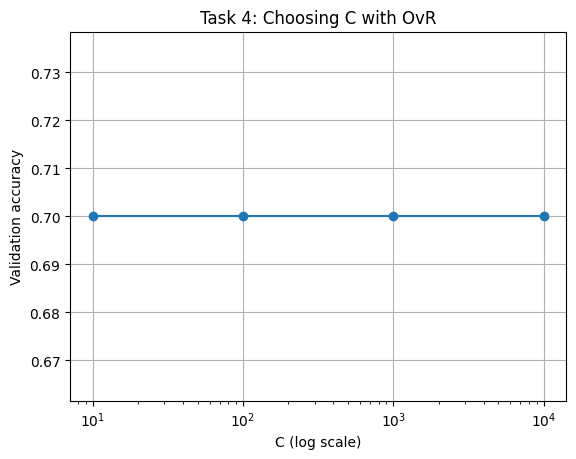

Test accuracy with best C: 78.0 %


In [59]:
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.

def balanced_subsample(X, y, max_per_class=30, random_state=42):
  """
  This grabs a small, balanced subset of the training set


  Training a kernel SVM with a QP solver gets slow fast as the number of points grows
  If we cap how many examples we take per class, T4 finishes in a reasonable time

  What it does:
  For each class label, it randomly picks up to max_per_class examples
  Then it merges everything together and shuffles the result

  Returns:
  X_sub, y_sub as numpy arrays
  """
  X_np = X.to_numpy() if hasattr(X, "to_numpy") else np.asarray(X)
  y_np = np.asarray(y).reshape(-1)

  rng = np.random.default_rng(random_state)

  chosen_indices = []
  for cls in np.unique(y_np):
    cls_idx = np.where(y_np == cls)[0]
    rng.shuffle(cls_idx)

    if max_per_class is not None and cls_idx.size > max_per_class:
      cls_idx = cls_idx[:max_per_class]

    chosen_indices.append(cls_idx)

  chosen_indices = np.concatenate(chosen_indices)
  rng.shuffle(chosen_indices)

  return X_np[chosen_indices], y_np[chosen_indices]

def stratified_split_indices(y, val_fraction=0.2, random_state=42):
  """
  This makes a train/validation split without messing up the class balance


  It splits each class separately so every class still shows up in both splits
  Then it combines the per-class pieces into one train index list and one val index list

  Returns:
  train_idx, val_idx (both are arrays of indices into y)
  """
  y = np.asarray(y).reshape(-1)
  rng = np.random.default_rng(random_state)

  train_parts = []
  val_parts = []

  for cls in np.unique(y):
    idx = np.where(y == cls)[0]
    rng.shuffle(idx)

    n_val = int(round(val_fraction * idx.size))

    n_val = max(1, n_val)
    n_val = min(n_val, idx.size - 1)

    val_parts.append(idx[:n_val])
    train_parts.append(idx[n_val:])

  train_idx = np.concatenate(train_parts)
  val_idx = np.concatenate(val_parts)

  rng.shuffle(train_idx)
  rng.shuffle(val_idx)

  return train_idx, val_idx

def ovr_predict(X_train, y_train, X_eval, C_value):
  """
  One-vs-Rest prediction


  Trains 1 binary SVM per class
  For class k,  label examples of k as +1 and everything else as -1
  Each SVM gives a decision score for every eval point
        pick the class with the highest score

  Returns  preds: predicted class labels for X_eval
  """
  classes = np.unique(y_train)
  scores = np.zeros((X_eval.shape[0], classes.size), dtype=float)

  for j, cls in enumerate(classes):
    y_bin = np.where(y_train == cls, 1.0, -1.0)

    model = SVM(kernel=nonlinear_kernel, C=float(C_value))
    model.fit(X_train, y_bin)

    scores[:, j] = model.decision_function(X_eval)

  preds = classes[np.argmax(scores, axis=1)]
  return preds

# These are the knobs i might actually want to change
max_per_class = 30
val_fraction = 0.2
random_state = 42

# This is the C grid we try
Cs = np.logspace(1, 4, 4)

# Get a balanced subset so training does not take forever
X_all, y_all = balanced_subsample(train_samples, train_samples_labels,max_per_class=max_per_class,random_state=random_state)

# Split that subset into a tuning train set and a validation set
train_idx, val_idx = stratified_split_indices(y_all,val_fraction=val_fraction, random_state=random_state)

X_tr = X_all[train_idx]
y_tr = y_all[train_idx]
X_val = X_all[val_idx]
y_val = y_all[val_idx]

# Pull test data into numpy so we can evaluate the final model at the end
X_test = test_samples.to_numpy() if hasattr(test_samples, "to_numpy") else np.asarray(test_samples)
y_test = np.asarray(test_samples_labels).reshape(-1)

print("C values we will try:", Cs)
print("Balanced subset shape:", X_all.shape)
print("Train split shape:", X_tr.shape, "Val split shape:", X_val.shape)

val_accs = []
train_times = []

for C_value in Cs:
  start = time.perf_counter()

  y_val_pred = ovr_predict(X_tr, y_tr, X_val, C_value)
  acc = float(np.mean(y_val_pred == y_val))

  end = time.perf_counter()

  val_accs.append(acc)
  train_times.append(end - start)

  print("C =", float(C_value), "val accuracy =", round(acc * 100, 2), "%", "time =", round(end - start, 2), "s")

val_accs = np.asarray(val_accs, dtype=float)
best_idx = int(np.argmax(val_accs))
best_C = float(Cs[best_idx])

print("Best C from validation:", best_C, "with val accuracy", round(val_accs[best_idx] * 100, 2), "%")

plt.figure()
plt.semilogx(Cs, val_accs, marker="o")
plt.xlabel("C (log scale)")
plt.ylabel("Validation accuracy")
plt.title("Task 4: Choosing C with OvR")
plt.grid(True)
plt.show()

# Now train again using all of the balanced subset with the best C
predictions_best = ovr_predict(X_all, y_all, X_test, best_C)
test_acc = float(np.mean(predictions_best == y_test))

print("Test accuracy with best C:", round(test_acc * 100, 2), "%")

# This is here so t5 can use `predictions` directly
predictions = predictions_best

## Task 5:
In addition to calculating percent accuracy, generate multiclass [confusion matrices](https://en.wikipedia.org/wiki/confusion_matrix) as part of your analysis.

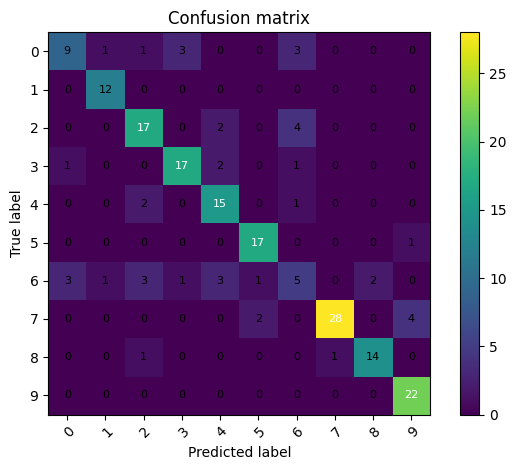

In [60]:
# Simple confusion matrix computation
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.
y_true = np.asarray(test_samples_labels).reshape(-1)
y_pred = np.asarray(predictions).reshape(-1)

classes = np.unique(np.concatenate([y_true, y_pred]))
class_to_index = {cls: i for i, cls in enumerate(classes)}

cm = np.zeros((classes.size, classes.size), dtype=int)
for t, p in zip(y_true, y_pred):
  cm[class_to_index[t], class_to_index[p]] += 1

fig, ax = plt.subplots()
im = ax.imshow(cm, interpolation="nearest")
ax.figure.colorbar(im, ax=ax)

ax.set(
  xticks=np.arange(classes.size),
  yticks=np.arange(classes.size),
  xticklabels=classes,
  yticklabels=classes
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion matrix")

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    ax.text(
      j,
      i,
      str(cm[i, j]),
      ha="center",
      va="center",
      color="white" if cm[i, j] > threshold else "black",
      fontsize=8
    )

fig.tight_layout()
plt.show()
#test


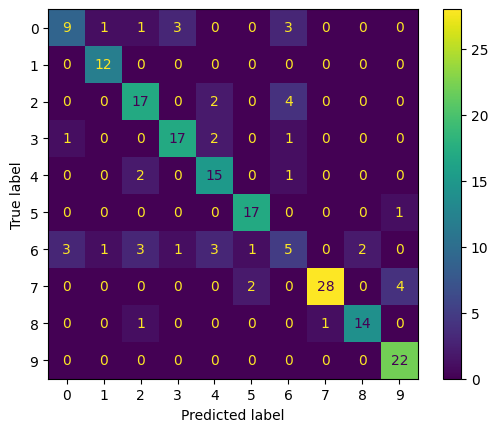

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test_samples_labels,predictions, labels=np.unique(test_samples_labels))
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=np.unique(test_samples_labels))
import matplotlib.pyplot as plt
cm_display.plot()
plt.show()

### What to Submit
Please submit the following:

1. A Jupyter noteboon that contains your completed notebook, where the output of each cell is clearly displayed.

2. A brief write-up that answers the 5 questions posed in this lab and justifies your model. Ensure that any figures you create are accessible and easy to understand.